In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
encoder = LabelEncoder()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
heart = pd.read_csv("/content/drive/MyDrive/Project Data Analysis/Bangkit Capstone Project/Dataset/Heart Disease.csv")

In [4]:
heart.head()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [5]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   impluse        1319 non-null   int64  
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   class          1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [6]:
heart.duplicated().sum()

0

In [7]:
df = heart.copy()

total_cases = len(df)
positive_cases = df[df['class'] == 'positive'].shape[0]
negative_cases = df[df['class'] == 'negative'].shape[0]

positive_percentage = (positive_cases / total_cases) * 100
negative_percentage = (negative_cases / total_cases) * 100

print("Number of True cases:  {0} ({1:2.2f}%)".format(positive_cases, positive_percentage))
print("Number of False cases: {0} ({1:2.2f}%)".format(negative_cases, negative_percentage))


Number of True cases:  810 (61.41%)
Number of False cases: 509 (38.59%)


In [8]:
categorical_columns = heart[["gender", "class"]]

In [9]:
# Check number of categories in each column
for column in categorical_columns.columns:
    print(f"Column: {column}")
    print(categorical_columns[column].value_counts())
    print()

Column: gender
gender
1    870
0    449
Name: count, dtype: int64

Column: class
class
positive    810
negative    509
Name: count, dtype: int64



In [10]:
df = heart.copy()
le_model = LabelEncoder()

df['class'] = le_model.fit_transform(df['class'])

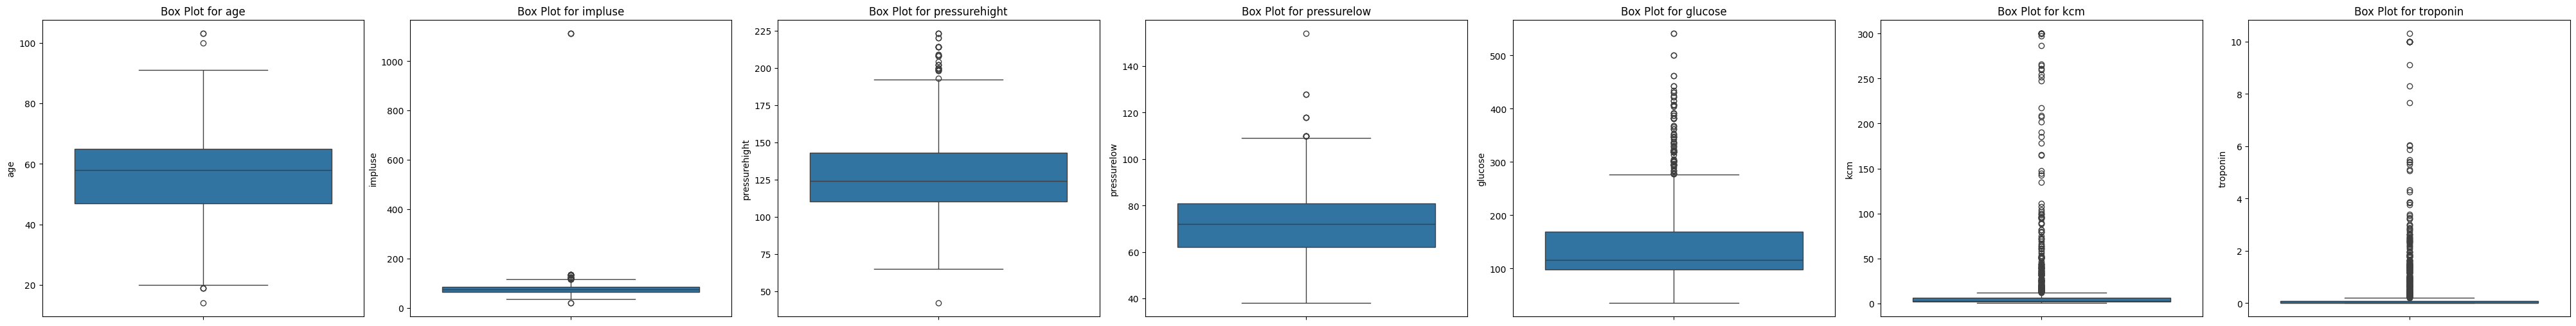

In [11]:
#Identifikasi outlier
numeric_columns = df.columns.drop(['class', 'gender'])
fig, axs = plt.subplots(ncols=len(numeric_columns), figsize=(40, 5))

for i, column in enumerate(numeric_columns):
    sns.boxplot(y=column, data=df, ax=axs[i], whis=1.5)
    axs[i].set_title(f'Box Plot for {column}')
    axs[i].set_xlabel('')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()

In [12]:
from scipy.stats.mstats import winsorize

# Winsorize setiap kolom
for column in numeric_columns:
    df[column] = winsorize(df[column], limits=[0.2, 0.2])

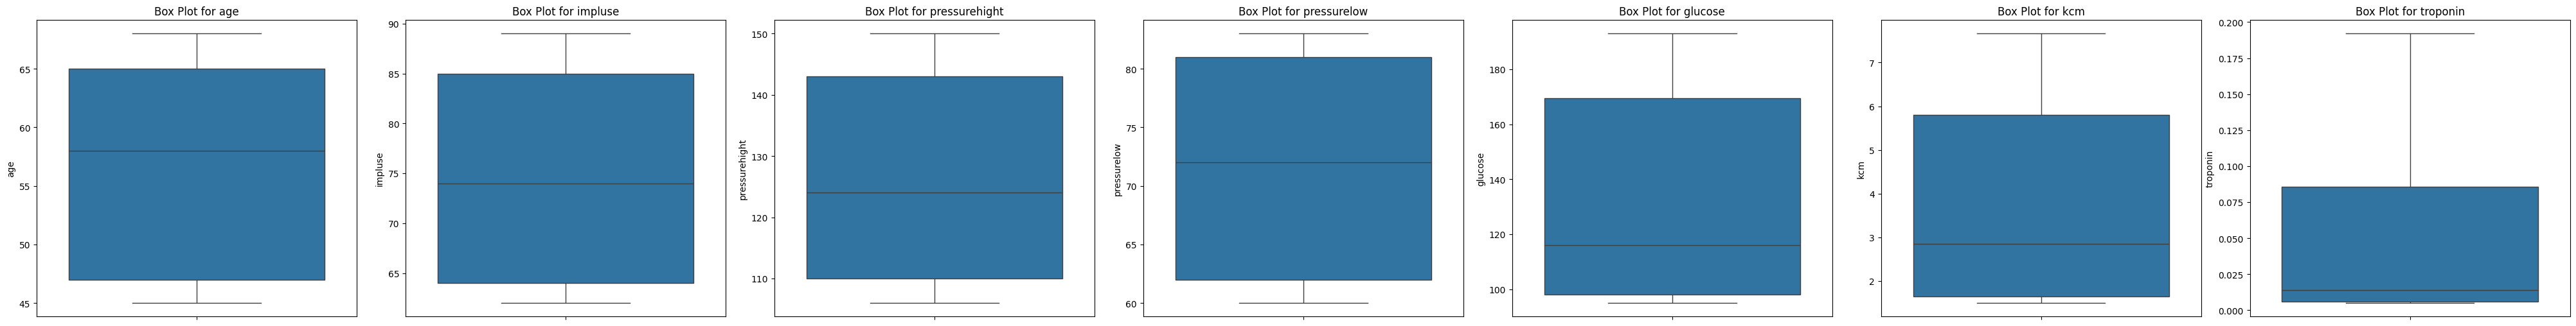

In [13]:
#Identifikasi outlier
numeric_columns = df.columns.drop(['class', 'gender'])
fig, axs = plt.subplots(ncols=len(numeric_columns), figsize=(40, 5))

for i, column in enumerate(numeric_columns):
    sns.boxplot(y=column, data=df, ax=axs[i], whis=1.5)
    axs[i].set_title(f'Box Plot for {column}')
    axs[i].set_xlabel('')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()

In [14]:
# Separate df_onehot to be X and y
X = df.drop(columns=['class'])  # Features
y = df['class']  # Target variable

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)
importances = model.feature_importances_

# Mengurutkan fitur berdasarkan pentingnya
indices = np.argsort(importances)[::-1]
for f in range(X.shape[1]):
    print(f"{X.columns[indices[f]]}: {importances[indices[f]]}")



troponin: 0.575901151156309
kcm: 0.2700589734996742
age: 0.050861703878951774
glucose: 0.025747918823879532
pressurehight: 0.02542531485357213
pressurelow: 0.022167768527296898
impluse: 0.0208076969038241
gender: 0.009029472356492357


In [16]:
# Mendapatkan feature importance
importances = model.feature_importances_

# Mengurutkan fitur berdasarkan feature importance
indices = np.argsort(importances)[::-1]

# Mendapatkan nama kolom dari 5 fitur teratas
top_features = [X.columns[indices[f]] for f in range(6)]
top_features

['troponin', 'kcm', 'age', 'glucose', 'pressurehight', 'pressurelow']

In [17]:
selected_features = df[['age','troponin', 'kcm', 'glucose', 'pressurehight', 'pressurelow', 'class']]

In [18]:
selected_features

,age,troponin,kcm,glucose,pressurehight,pressurelow,class
0,64,0.012,1.80,160.0,150,83,0
1,45,0.192,6.75,193.0,106,60,1
2,55,0.005,1.99,193.0,150,77,0
3,64,0.122,7.66,193.0,120,60,1
4,55,0.005,1.50,193.0,112,65,0
...,...,...,...,...,...,...,...
1314,45,0.006,1.63,193.0,122,67,0
1315,66,0.172,1.50,149.0,125,60,1
1316,45,0.192,1.50,96.0,150,83,1
1317,54,0.192,5.80,193.0,117,68,1


In [19]:
selected_features.duplicated().sum()

2

In [20]:
df_new = selected_features.drop_duplicates()

In [21]:
X = df_new.drop(columns = 'class', axis = 1)
y = df_new['class']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14045, stratify=y)

In [23]:
# Feature Scaling

from sklearn.preprocessing import Normalizer

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)


Epoch 1/500
27/27 [==============================] - 4s 27ms/step - loss: 0.6783 - accuracy: 0.6057 - val_loss: 0.6851 - val_accuracy: 0.5735
Epoch 2/500
27/27 [==============================] - 0s 7ms/step - loss: 0.6752 - accuracy: 0.6200 - val_loss: 0.6826 - val_accuracy: 0.5829
Epoch 3/500
27/27 [==============================] - 0s 15ms/step - loss: 0.6723 - accuracy: 0.6295 - val_loss: 0.6804 - val_accuracy: 0.6066
Epoch 4/500
27/27 [==============================] - 0s 10ms/step - loss: 0.6694 - accuracy: 0.6271 - val_loss: 0.6781 - val_accuracy: 0.6066
Epoch 5/500
27/27 [==============================] - 0s 8ms/step - loss: 0.6664 - accuracy: 0.6330 - val_loss: 0.6759 - val_accuracy: 0.6066
Epoch 6/500
27/27 [==============================] - 0s 8ms/step - loss: 0.6634 - accuracy: 0.6354 - val_loss: 0.6736 - val_accuracy: 0.6066
Epoch 7/500
27/27 [==============================] - 0s 8ms/step - loss: 0.6603 - accuracy: 0.6354 - val_loss: 0.6712 - val_accuracy: 0.6066
Epoch 8/50

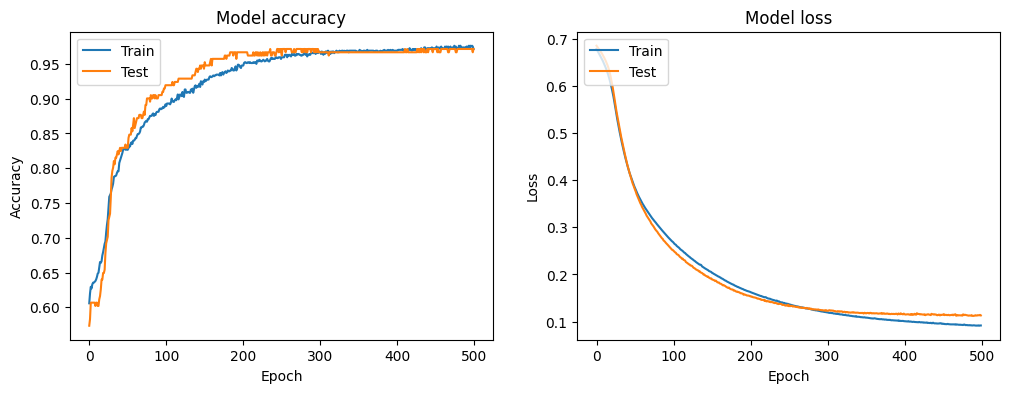

9/9 [==============================] - 0s 3ms/step


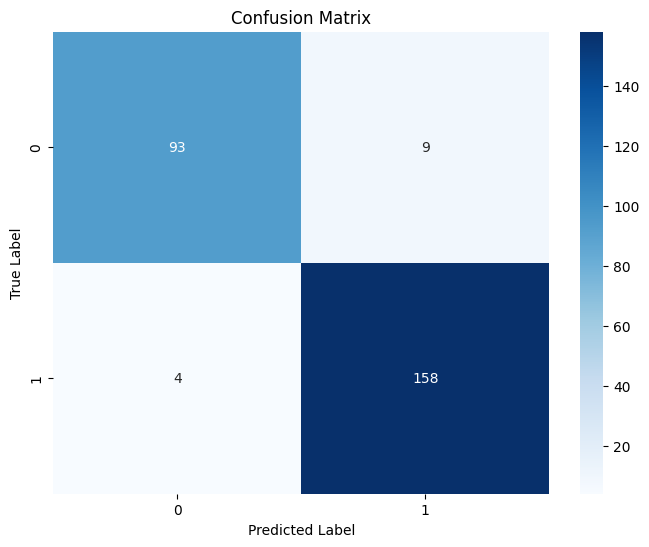

In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from keras.optimizers import SGD, Adam, RMSprop, Nadam
# Build model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32,input_dim = X_train.shape[1], activation = "relu"),
    tf.keras.layers.Dense(16,activation = "relu"),
    tf.keras.layers.Dense(8,activation = "relu"),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train model and store the history
history = model.fit(X_train, y_train, epochs=500, batch_size=32, validation_split = 0.2)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()

# Predict the values from the test dataset
y_pred = model.predict(X_test)
y_pred_classes = np.round(y_pred).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [30]:
# Confusion matrix summary

from sklearn.metrics import classification_report

# Get the classification report
report = classification_report(y_test, y_pred_classes)

# Print the report
print(report)


              precision    recall  f1-score   support

           0       0.96      0.91      0.93       102
           1       0.95      0.98      0.96       162

    accuracy                           0.95       264
   macro avg       0.95      0.94      0.95       264
weighted avg       0.95      0.95      0.95       264



In [25]:
y_test.value_counts()

class
1    162
0    102
Name: count, dtype: int64

In [28]:
# Use new model to predict new data

# New data
new_data = [[51,	0.192,	7.66,	134.0,	150,	79]]

# Scale new data
new_data_scaled = scaler.transform(new_data)

# Predict new data
prediction = model.predict(new_data_scaled)

# Convert prediction to class label
predicted_class = np.round(prediction).astype(int)

# Print the predicted class
print(f"Predicted class: {predicted_class[0]}")


1/1 [==============================] - 0s 21ms/step
Predicted class: [1]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [29]:
# Use new model to predict new data

# New data
new_data = [[45,	0.006,	1.63,	193.0,122,	67	]]

# Scale new data
new_data_scaled = scaler.transform(new_data)

# Predict new data
prediction = model.predict(new_data_scaled)

# Convert prediction to class label
predicted_class = np.round(prediction).astype(int)

# Print the predicted class
print(f"Predicted class: {predicted_class[0]}")


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 [==============================] - 0s 48ms/step
Predicted class: [0]
